# Notebook 06 — Análisis exploratorio de la extracción LLM por vídeo

A partir del consolidado `llm_priority_dataset.parquet` generado en el notebook 05, este notebook realiza un análisis exploratorio de las variables inferidas por el LLM a nivel de vídeo.

El objetivo no es todavía construir el target final de modelado, sino revisar la calidad de la extracción, estudiar la distribución temporal de la actividad y detectar patrones útiles para pasar después a una formulación de clasificación.

## Objetivo

- Cargar el consolidado final del notebook 05 y validar su estructura.
- Recuperar metadatos originales del conjunto priorizado mediante un cruce por `video_id`.
- Analizar la distribución de actividad, certeza y especies detectadas.
- Revisar cobertura temporal por año y trimestre.
- Identificar casos ambiguos y posibles fuentes de ruido.
- Dejar una base analítica clara para construir el target categórico en el notebook 07.

## Preparación del entorno

Montaje de Google Drive e importación de librerías necesarias para el análisis exploratorio del consolidado LLM.

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Carga del consolidado LLM y validación inicial

Se carga el dataset consolidado generado en el notebook 05 y se comprueba su forma, número de vídeos únicos, cobertura temporal y estructura general de las variables inferidas por el LLM.

In [13]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE_DIR = Path("/content/drive/MyDrive/PIDS4jjj2")
OUT_DIR = BASE_DIR / "outputs" / "llm_activity"

FINAL_PATH = OUT_DIR / "llm_priority_dataset.parquet"

df = pd.read_parquet(FINAL_PATH)

print("Shape:", df.shape)
print("Columnas:", df.columns.tolist())
df.head()

Shape: (151, 8)
Columnas: ['video_id', 'activity_mentions_llm', 'captures_count_llm', 'species_detected_llm', 'activity_level_llm', 'certainty_llm', 'evidence_llm', 'notes_llm']


,video_id,activity_mentions_llm,captures_count_llm,species_detected_llm,activity_level_llm,certainty_llm,evidence_llm,notes_llm
0,K2oTCf-5C4c,1,NaN,"[carpa, barbo, lucio, bass]",low,medium,salidas de pesca en varias modalidades y sobre...,"Se menciona actividad de pesca y modalidades, ..."
1,KYkoHio90Pw,1,NaN,"[carpa, lucioperca]",high,high,Sorpresas con peces grandes en lagos urbanos d...,Hay actividad pesquera clara y capturas mencio...
2,TvT1jlG9ayw,1,NaN,"[lucio, carpa]",low,medium,"se pueden recorrer en bici o a pie, hacer pira...",Vídeo descriptivo del entorno; menciona pesca ...
3,kt78DbVibg0,1,NaN,[carpa],high,high,LLUVIA y MUCHAS CAPTURAS; las carpas dieron la...,"Capturas claras, pero sin número exacto."
4,dZfMo3t8TWo,1,NaN,[carpa],high,high,sesión increíble en solitario en valma con dob...,"Se mencionan picadas y carpas, pero no número ..."


## Recuperación de metadatos originales

El consolidado generado en el notebook 05 contiene únicamente las variables inferidas por el LLM. Para el análisis temporal y contextual de este notebook, se recuperan metadatos originales del subconjunto priorizado mediante un cruce por `video_id`.

In [14]:
PRIORITY_PATH = OUT_DIR / "candidates_priority.parquet"

df_priority = pd.read_parquet(PRIORITY_PATH)

print("Shape candidates_priority:", df_priority.shape)
df_priority.head()

Shape candidates_priority: (151, 38)


,video_id,title,description,channel,channel_id,uploader,published_at,year,month,quarter,...,has_lucioperca_terms,has_spinning_terms,has_species_or_modality_terms,candidate_score,is_text_too_short,is_title_too_short,has_weak_context,has_no_valmayor,is_very_short_video,priority_score
0,K2oTCf-5C4c,rubenylolo......carpfishing 🤍🩵,#Carpfishing #otoñal #fishing #pesca #pescaria...,RubenYlolo,UCdv-Xd3cLlJT0CF9kdmZhcw,RubenYlolo,2026-04-30,2026,4,2,...,False,True,True,8,False,False,False,False,False,21
1,KYkoHio90Pw,Carpfishing 🥵 🔥Summer Campaign 🔥🥵 HOT FISHING🎣,CARPFISHING🥵 SUMMER🥵 CAMPAIGN 🔥🎣\n#pesca #fish...,Gerar Carp_angler,UC1z_zXQcdl6jqFYnMozTatg,Gerar Carp_angler,2026-02-25,2026,2,1,...,True,False,True,8,False,False,False,False,False,18
2,TvT1jlG9ayw,El embalse de Valmayor y su entorno,Visita nuestra web: http://www.infosierrademad...,Infosierrademadrid.es,UC62wX016CjABYJSHeP2RppQ,Infosierrademadrid.es,2016-07-18,2016,7,3,...,False,False,True,8,False,False,False,False,False,18
3,kt78DbVibg0,¡LLUVIA y MUCHAS CAPTURAS! 💥 Carp Fishing bajo...,Sesion de carpfishing en el embalse de valmayo...,RubenYlolo,UCdv-Xd3cLlJT0CF9kdmZhcw,RubenYlolo,2025-11-05,2025,11,4,...,False,False,True,8,False,False,False,False,False,18
4,dZfMo3t8TWo,🔥Sesion increíble!! 🔥en solitario en valma con...,Una de esas sesiones que a veces nos brinda nu...,RubenYlolo,UCdv-Xd3cLlJT0CF9kdmZhcw,RubenYlolo,2025-10-16,2025,10,4,...,False,False,True,8,False,False,False,False,False,18


In [15]:
meta_cols = [
    "video_id",
    "title",
    "channel",
    "year",
    "year_quarter",
    "priority_score"
]

meta_cols_existing = [c for c in meta_cols if c in df_priority.columns]
print("Columnas metadata recuperables:", meta_cols_existing)

Columnas metadata recuperables: ['video_id', 'title', 'channel', 'year', 'year_quarter', 'priority_score']


In [16]:
df = df.merge(
    df_priority[meta_cols_existing].drop_duplicates(subset=["video_id"]),
    on="video_id",
    how="left"
)

print("Shape tras merge:", df.shape)
df.head()

Shape tras merge: (151, 13)


,video_id,activity_mentions_llm,captures_count_llm,species_detected_llm,activity_level_llm,certainty_llm,evidence_llm,notes_llm,title,channel,year,year_quarter,priority_score
0,K2oTCf-5C4c,1,NaN,"[carpa, barbo, lucio, bass]",low,medium,salidas de pesca en varias modalidades y sobre...,"Se menciona actividad de pesca y modalidades, ...",rubenylolo......carpfishing 🤍🩵,RubenYlolo,2026.0,2026-Q2,21.0
1,KYkoHio90Pw,1,NaN,"[carpa, lucioperca]",high,high,Sorpresas con peces grandes en lagos urbanos d...,Hay actividad pesquera clara y capturas mencio...,Carpfishing 🥵 🔥Summer Campaign 🔥🥵 HOT FISHING🎣,Gerar Carp_angler,2026.0,2026-Q1,18.0
2,TvT1jlG9ayw,1,NaN,"[lucio, carpa]",low,medium,"se pueden recorrer en bici o a pie, hacer pira...",Vídeo descriptivo del entorno; menciona pesca ...,El embalse de Valmayor y su entorno,Infosierrademadrid.es,2016.0,2016-Q3,18.0
3,kt78DbVibg0,1,NaN,[carpa],high,high,LLUVIA y MUCHAS CAPTURAS; las carpas dieron la...,"Capturas claras, pero sin número exacto.",¡LLUVIA y MUCHAS CAPTURAS! 💥 Carp Fishing bajo...,RubenYlolo,2025.0,2025-Q4,18.0
4,dZfMo3t8TWo,1,NaN,[carpa],high,high,sesión increíble en solitario en valma con dob...,"Se mencionan picadas y carpas, pero no número ...",🔥Sesion increíble!! 🔥en solitario en valma con...,RubenYlolo,2025.0,2025-Q4,18.0


## Validación inicial del consolidado enriquecido

Se comprueba el número de vídeos únicos, la cobertura de variables clave y la consistencia básica del dataset antes de entrar en el análisis exploratorio.

In [18]:
print("Filas:", len(df))
print("Vídeos únicos:", df["video_id"].nunique())

for col in ["activity_mentions_llm", "captures_count_llm", "activity_level_llm", "certainty_llm"]:
    if col in df.columns:
        print(f"No nulos en {col}:", df[col].notna().sum())

Filas: 151
Vídeos únicos: 151
No nulos en activity_mentions_llm: 151
No nulos en captures_count_llm: 52
No nulos en activity_level_llm: 151
No nulos en certainty_llm: 151


## Distribución temporal del conjunto

Se revisa cómo se reparte la muestra por año y por trimestre. Esta cobertura temporal condicionará más adelante la construcción del target y el tipo de modelado que se podrá defender.

In [19]:
print("Distribución por año:")
display(df["year"].value_counts().sort_index())

print("\nDistribución por trimestre:")
display(df["year_quarter"].value_counts().sort_index())

Distribución por año:


,count
year,
2009.0,3
2010.0,3
2011.0,6
2012.0,4
2013.0,7
2014.0,10
2015.0,2
2016.0,3
2017.0,7



Distribución por trimestre:


,count
year_quarter,
2009-Q3,2
2009-Q4,1
2010-Q1,1
2010-Q2,2
2011-Q1,1
2011-Q3,3
2011-Q4,2
2012-Q2,1
2012-Q3,2


## Distribución de variables LLM

Se analizan las variables principales inferidas por el modelo: presencia de actividad pesquera, nivel cualitativo de actividad y nivel de certeza.

In [20]:
print("Distribución activity_mentions_llm:")
display(df["activity_mentions_llm"].value_counts(dropna=False).sort_index())

print("\nDistribución activity_level_llm:")
display(df["activity_level_llm"].value_counts(dropna=False))

print("\nDistribución certainty_llm:")
display(df["certainty_llm"].value_counts(dropna=False))

Distribución activity_mentions_llm:


,count
activity_mentions_llm,
0,9
1,142



Distribución activity_level_llm:


,count
activity_level_llm,
medium,65
low,59
high,27



Distribución certainty_llm:


,count
certainty_llm,
high,83
medium,51
low,17


## Capturas explícitas

No todos los vídeos contienen un número concreto de capturas. En este bloque se revisa cuántos vídeos aportan una cuantificación explícita y cómo se distribuyen esos valores.

In [21]:
captures_non_null = df["captures_count_llm"].notna().sum()
captures_zero = (df["captures_count_llm"] == 0).sum()
captures_positive = (df["captures_count_llm"].fillna(-1) > 0).sum()

print("Vídeos con captures_count_llm no nulo:", captures_non_null)
print("Vídeos con 0 capturas explícitas:", captures_zero)
print("Vídeos con capturas explícitas > 0:", captures_positive)

Vídeos con captures_count_llm no nulo: 52
Vídeos con 0 capturas explícitas: 3
Vídeos con capturas explícitas > 0: 49


In [22]:
df[df["captures_count_llm"].notna()][
    ["video_id", "year", "year_quarter", "captures_count_llm", "activity_level_llm", "certainty_llm", "species_detected_llm", "evidence_llm"]
].sort_values("captures_count_llm", ascending=False).head(20)

,video_id,year,year_quarter,captures_count_llm,activity_level_llm,certainty_llm,species_detected_llm,evidence_llm
7,97L3xUDkpxQ,2014.0,2014-Q2,33.0,high,high,[carpa],43 picadas y 33 capturas de carpfishing Valmayor
40,ZTTybKLjKGQ,2025.0,2025-Q2,25.0,high,high,[carpa],sacamos 25 carpas en total
11,lUoF43gjK20,2014.0,2014-Q2,23.0,high,high,[carpa],33 picadas y 23 capturas de Carpfishing Valmayor
9,5daoPKGBVpI,2015.0,2015-Q1,20.0,high,high,[carpa],más de 30 picadas y más de 20 capturas
104,J6J6g2nzG_k,2021.0,2021-Q2,20.0,high,high,[carpa],pudimos sacar mas de 20 peces
44,GULtU5Z4iz4,2018.0,2018-Q4,13.0,high,high,[carpa],Sesión de 12 horas en el acotado de Valmayor d...
66,97BYJ9fuuio,2017.0,2017-Q3,11.0,high,high,[carpa],11 capturas en 8 horas
52,ehQURnQTvQU,2018.0,2018-Q3,8.0,high,high,[carpa],En total 8 capturas
36,pbr8x7An1aM,2018.0,2018-Q4,7.0,high,high,[carpa],jornada de carpfishing de 10 horas con un tota...
41,WLEsz1gH-Ik,2019.0,2019-Q4,5.0,medium,high,[carpa],jornada de carpfishing de 10 horas con un tota...


## Especies y modalidades detectadas

Se revisa la frecuencia de especies o modalidades mencionadas por el LLM. Esta información ayuda a comprobar si la ampliación del scraping hacia distintas especies está realmente reflejada en la muestra final.

In [23]:
species_exploded = df.explode("species_detected_llm").copy()
species_exploded["species_detected_llm"] = species_exploded["species_detected_llm"].fillna("sin_especie")

display(species_exploded["species_detected_llm"].value_counts().head(20))

,count
species_detected_llm,
carpa,107
sin_especie,17
lucio,16
carpa royal,8
lucioperca,6
carpa común,4
barbo,2
bass,1
lisa,1


## Evolución temporal de especies y modalidades

Además de la frecuencia global, interesa comprobar cómo se distribuyen las especies detectadas a lo largo del tiempo. Esto permite verificar si la ampliación del scraping está reflejada también en la dimensión temporal del dataset.

In [24]:
species_by_year = (
    species_exploded.groupby(["year", "species_detected_llm"])
    .size()
    .reset_index(name="count")
    .sort_values(["year", "count"], ascending=[True, False])
)

species_by_year.head(30)

,year,species_detected_llm,count
1,2009.0,lucio,2
0,2009.0,carpa,1
3,2010.0,lucio,2
2,2010.0,carpa,1
6,2011.0,lucio,3
4,2011.0,carpa,1
5,2011.0,carpa royal,1
7,2011.0,sin_especie,1
8,2012.0,carpa,3
9,2012.0,lucio,1


In [25]:
species_by_quarter = (
    species_exploded.groupby(["year_quarter", "species_detected_llm"])
    .size()
    .reset_index(name="count")
    .sort_values(["year_quarter", "count"], ascending=[True, False])
)

species_by_quarter.head(30)

,year_quarter,species_detected_llm,count
0,2009-Q3,carpa,1
1,2009-Q3,lucio,1
2,2009-Q4,lucio,1
3,2010-Q1,carpa,1
4,2010-Q2,lucio,2
5,2011-Q1,lucio,1
6,2011-Q3,carpa royal,1
7,2011-Q3,lucio,1
8,2011-Q3,sin_especie,1
9,2011-Q4,carpa,1


## Casos ambiguos o potencialmente ruidosos

No todos los vídeos aportan la misma calidad semántica. En este bloque se revisan vídeos con baja certeza o con ausencia de actividad clara para identificar posibles fuentes de ruido antes de construir el target final.

In [26]:
df[
    (df["activity_mentions_llm"] == 0) |
    (df["certainty_llm"] == "low")
][
    ["video_id", "year", "year_quarter", "activity_mentions_llm", "captures_count_llm", "species_detected_llm", "activity_level_llm", "certainty_llm", "evidence_llm", "notes_llm"]
].head(25)

,video_id,year,year_quarter,activity_mentions_llm,captures_count_llm,species_detected_llm,activity_level_llm,certainty_llm,evidence_llm,notes_llm
5,uTM2DGKH-xw,2021.0,2021-Q2,0,NaN,[],low,high,diseñamos y producimos todo tipo de accesorios...,"Vídeo de producto/accesorios, no describe una ..."
58,sAqCNMsD3P0,2014.0,2014-Q3,1,NaN,[carpa],low,low,Carpfishing///Mcarp-Embalse de Valmayor,"El título indica carpfishing en Valmayor, pero..."
61,ZjnrwnzMVho,2024.0,2024-Q3,1,NaN,[carpa],low,low,"embalse de valmayor, carpfishing en familia",Solo hay título; actividad de carpfishing clar...
62,CO7haWIMlcg,2012.0,2012-Q3,1,NaN,[carpa],low,low,Carpas embalse Valmayor,Solo hay título; no se puede confirmar captura...
65,-hkkm9oNFeY,2018.0,2018-Q4,0,NaN,[],low,high,diseñamos y producimos todo tipo de accesorios...,"Vídeo de producto/accesorio, no una jornada de..."
68,26JkSUvd050,2021.0,2021-Q3,0,NaN,[],low,high,diseñamos y producimos todo tipo de accesorios...,"Vídeo de producto/accesorio, no describe activ..."
80,0rTQOlm2rO8,2026.0,2026-Q2,1,NaN,[carpa],low,low,Pesca Carp Embalse de Valmayor,Solo hay título; actividad clara pero sin capt...
107,apw2MmnMDeA,2018.0,2018-Q1,1,NaN,[carpa],low,low,Carpfishing///Mcarp-Winter in Valmayor,Solo hay título; actividad de carpfishing clar...
118,feZ13jeezAk,2023.0,2023-Q2,1,NaN,[carpa],low,low,carpfishing en valmayor,"Solo hay título; actividad clara, sin capturas."
119,M-3nBo79IFI,2013.0,2013-Q3,1,NaN,[carpa],low,low,"Extreme carpfishing in Spain, Valmayor","Solo hay título; actividad clara, sin capturas..."


In [27]:
df.sort_values("captures_count_llm", ascending=False)[
    ["video_id", "year", "year_quarter", "captures_count_llm", "species_detected_llm", "activity_level_llm", "certainty_llm", "notes_llm"]
].head(20)

,video_id,year,year_quarter,captures_count_llm,species_detected_llm,activity_level_llm,certainty_llm,notes_llm
7,97L3xUDkpxQ,2014.0,2014-Q2,33.0,[carpa],high,high,Actividad y capturas explícitas.
40,ZTTybKLjKGQ,2025.0,2025-Q2,25.0,[carpa],high,high,Capturas explícitas.
11,lUoF43gjK20,2014.0,2014-Q2,23.0,[carpa],high,high,Actividad y capturas explícitas.
9,5daoPKGBVpI,2015.0,2015-Q1,20.0,[carpa],high,high,Se usa 20 como mínimo explícito al decir más d...
104,J6J6g2nzG_k,2021.0,2021-Q2,20.0,[carpa],high,high,Se usa 20 como mínimo explícito; el lugar indi...
44,GULtU5Z4iz4,2018.0,2018-Q4,13.0,[carpa],high,high,Capturas explícitas.
66,97BYJ9fuuio,2017.0,2017-Q3,11.0,[carpa],high,high,Capturas explícitas por título.
52,ehQURnQTvQU,2018.0,2018-Q3,8.0,[carpa],high,high,Capturas explícitas en una sesión de carpfishi...
36,pbr8x7An1aM,2018.0,2018-Q4,7.0,[carpa],high,high,Capturas explícitas.
41,WLEsz1gH-Ik,2019.0,2019-Q4,5.0,[carpa],medium,high,Capturas explícitas.


## Distribución temporal de la actividad cualitativa

Como el siguiente paso del pipeline será reformular el problema como clasificación, resulta útil estudiar cómo se reparte la variable `activity_level_llm` a lo largo de los años y de los trimestres.

In [28]:
activity_by_year = (
    df.groupby(["year", "activity_level_llm"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

activity_by_year

activity_level_llm,high,low,medium
year,,,
2009.0,0,2,1
2010.0,0,1,2
2011.0,0,1,5
2012.0,0,3,1
2013.0,0,3,4
2014.0,2,4,4
2015.0,1,0,1
2016.0,0,2,1
2017.0,2,1,4


In [29]:
activity_by_quarter = (
    df.groupby(["year_quarter", "activity_level_llm"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

activity_by_quarter.tail(20)

activity_level_llm,high,low,medium
year_quarter,,,
2021-Q1,1,1,2
2021-Q2,3,6,4
2021-Q3,0,2,1
2021-Q4,1,2,2
2022-Q1,2,0,0
2022-Q2,0,2,1
2022-Q3,0,0,2
2022-Q4,0,1,1
2023-Q1,0,0,2


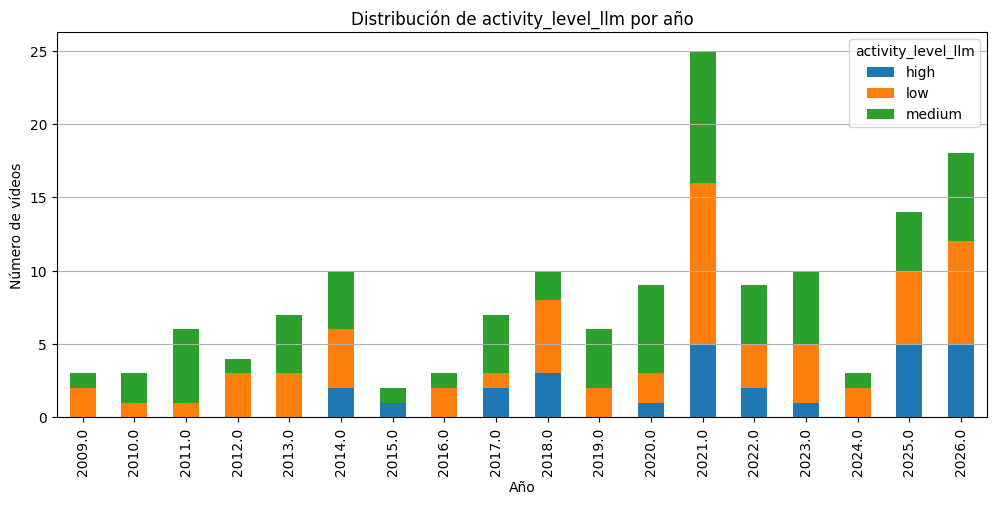

In [32]:
import matplotlib.pyplot as plt

activity_by_year.plot(kind="bar", stacked=True, figsize=(12,5))
plt.title("Distribución de activity_level_llm por año")
plt.xlabel("Año")
plt.ylabel("Número de vídeos")
plt.grid(axis="y")
plt.show()

## Distribución temporal de la certeza

La variable `certainty_llm` permite distinguir entre vídeos con señal más clara y vídeos más ambiguos. Esta distribución es útil para decidir más adelante si conviene filtrar ciertos casos al construir el target de clasificación.

In [33]:
certainty_by_year = (
    df.groupby(["year", "certainty_llm"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

certainty_by_year

certainty_llm,high,low,medium
year,,,
2009.0,1,1,1
2010.0,1,0,2
2011.0,4,1,1
2012.0,0,1,3
2013.0,5,2,0
2014.0,4,1,5
2015.0,2,0,0
2016.0,0,0,3
2017.0,4,0,3


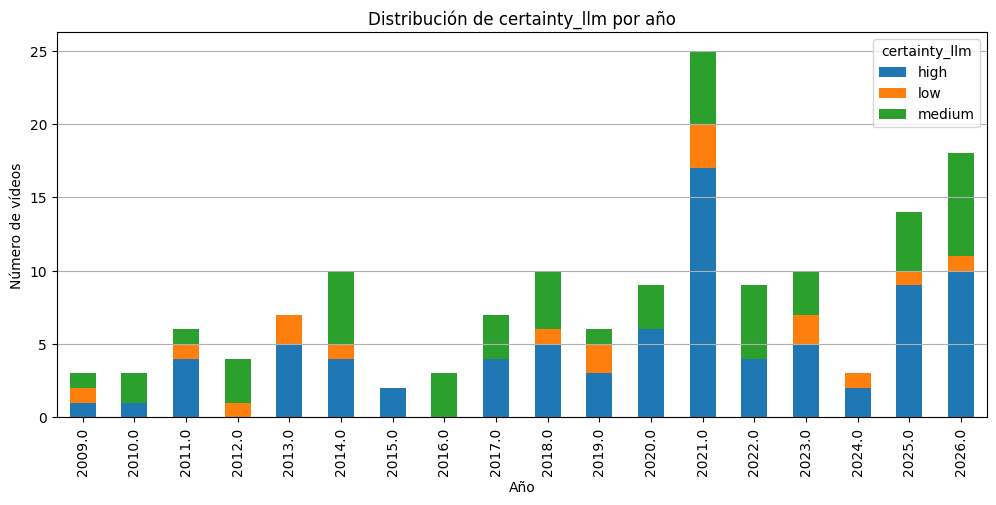

In [34]:
certainty_by_year.plot(kind="bar", stacked=True, figsize=(12,5))
plt.title("Distribución de certainty_llm por año")
plt.xlabel("Año")
plt.ylabel("Número de vídeos")
plt.grid(axis="y")
plt.show()

## Persistencia de tablas auxiliares

Se guardan algunas tablas analíticas que pueden reutilizarse más adelante en la construcción del target y en la redacción de la memoria.

In [35]:
activity_by_year_path = OUT_DIR / "llm_activity_level_by_year.csv"
activity_by_quarter_path = OUT_DIR / "llm_activity_level_by_quarter.csv"
species_by_year_path = OUT_DIR / "llm_species_by_year.csv"
species_by_quarter_path = OUT_DIR / "llm_species_by_quarter.csv"
certainty_by_year_path = OUT_DIR / "llm_certainty_by_year.csv"

activity_by_year.to_csv(activity_by_year_path)
activity_by_quarter.to_csv(activity_by_quarter_path)
species_by_year.to_csv(species_by_year_path, index=False)
species_by_quarter.to_csv(species_by_quarter_path, index=False)
certainty_by_year.to_csv(certainty_by_year_path)

print(activity_by_year_path)
print(activity_by_quarter_path)
print(species_by_year_path)
print(species_by_quarter_path)
print(certainty_by_year_path)

/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/llm_activity_level_by_year.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/llm_activity_level_by_quarter.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/llm_species_by_year.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/llm_species_by_quarter.csv
/content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/llm_certainty_by_year.csv


## Conclusión

El análisis exploratorio de la extracción LLM confirma que el pipeline ya dispone de una muestra más amplia y más variada que en la versión inicial del proyecto. La señal generada por el LLM no solo recoge presencia de actividad pesquera, sino también niveles cualitativos de actividad, especies detectadas y niveles de certeza, lo que resulta más adecuado para una reformulación posterior del problema como tarea de clasificación.

La especie dominante sigue siendo la carpa, algo esperable por el tipo de contenido recuperado, pero ya aparecen también otras señales como lucio, lucioperca, bass o barbo. Esto indica que la ampliación del scraping hacia varias especies y modalidades sí se ha trasladado al dataset final, aunque de forma todavía desigual.

A nivel temporal, la cobertura por años y trimestres sigue siendo irregular, pero suficiente para justificar una construcción posterior del target categórico sobre agregaciones temporales más finas que la anual. En este sentido, el trimestre parece una unidad más razonable que el año completo para la siguiente fase del pipeline.

En conjunto, este notebook valida que la extracción LLM aporta una señal interpretable, útil y alineada con la nueva orientación metodológica del TFG. El siguiente paso será construir en el notebook 07 un target de clasificación.